In [1]:
from ta.volatility import BollingerBands, AverageTrueRange
from ta.momentum import RSIIndicator
from ta.trend import EMAIndicator

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from backtesting import Strategy
from backtesting import Backtest

c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [2]:
start_date = '2026-1-1 00:00'
end_date = '2026-12-30 00:00'
# start_date = '2022-01-1 00:00'
# end_date = '2026-9-16 00:00'
pair = 'GBPJPY'
timezone = "Europe/London"

In [3]:
# read data
df_h1_raw = pd.read_csv(f"./Trading Data/{pair}_H1.csv",sep=',', parse_dates=['Date'], index_col='Date')

df_h1_raw

,Open,High,Low,Close,Tickvol
Date,,,,,
2018-08-07 11:00:00,144.154,144.204,144.088,144.134,5948
2018-08-07 12:00:00,144.133,144.149,144.012,144.062,6595
2018-08-07 13:00:00,144.062,144.075,143.808,143.932,7891
2018-08-07 14:00:00,143.933,143.949,143.815,143.869,7951
2018-08-07 15:00:00,143.869,144.088,143.863,144.087,8342
...,...,...,...,...,...
2026-09-24 10:00:00,209.795,210.067,209.795,210.017,13720
2026-09-24 11:00:00,210.017,210.047,209.813,209.996,13711
2026-09-24 12:00:00,209.997,210.105,209.874,210.005,12834


In [4]:
# process
df_h1 = df_h1_raw.loc[start_date : end_date]

# Calculate Bollinger Bands and RSI using pandas_ta
bollinger_indicator = BollingerBands(close=df_h1['Close'], window=30, window_dev=2)
df_h1['bbh'] = bollinger_indicator.bollinger_hband()
df_h1['bbl'] = bollinger_indicator.bollinger_lband()
df_h1['bbm'] = bollinger_indicator.bollinger_mavg()

indicator_rsi_14 = RSIIndicator(df_h1['Close'], window=14)
df_h1['rsi'] = indicator_rsi_14.rsi()

indicator_atr_14 = AverageTrueRange(df_h1['High'], df_h1['Low'], df_h1['Close'], window=14)
df_h1["atr"] = indicator_atr_14.average_true_range()

# Calculate Bollinger Bands Width
df_h1['bb_width'] = (df_h1['bbh'] - df_h1['bbl']) / df_h1['bbm']

indicator_ema_50 = EMAIndicator(df_h1['Close'], window=50)
df_h1['EMA_50'] = indicator_ema_50.ema_indicator()

indicator_ema_200 = EMAIndicator(df_h1['Close'], window=200)
df_h1['EMA_200'] = indicator_ema_200.ema_indicator()

df_h1


,Open,High,Low,Close,Tickvol,bbh,bbl,bbm,rsi,atr,bb_width,EMA_50,EMA_200
Date,,,,,,,,,,,,,
2026-01-01 23:00:00,210.689,211.068,210.574,211.068,1267,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2026-01-02 00:00:00,211.067,211.347,211.018,211.161,4726,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2026-01-02 01:00:00,211.162,211.221,211.029,211.069,3370,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2026-01-02 02:00:00,211.068,211.272,211.014,211.257,4029,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
2026-01-02 03:00:00,211.258,211.341,211.198,211.330,2082,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-24 10:00:00,209.795,210.067,209.795,210.017,13720,210.189836,209.022097,209.605967,58.893603,0.285732,0.005571,209.720696,209.698042
2026-09-24 11:00:00,210.017,210.047,209.813,209.996,13711,210.205531,209.016469,209.611000,58.364699,0.282037,0.005673,209.731493,209.701007
2026-09-24 12:00:00,209.997,210.105,209.874,210.005,12834,210.218862,209.011472,209.615167,58.536562,0.278392,0.005760,209.742218,209.704031


In [5]:
df_h1.describe()

,Open,High,Low,Close,Tickvol,bbh,bbl,bbm,rsi,atr,bb_width,EMA_50,EMA_200
count,4486.000000,4486.000000,4486.000000,4486.000000,4486.000000,4457.000000,4457.000000,4457.000000,4473.000000,4486.000000,4457.000000,4437.000000,4287.000000
mean,213.252153,213.375346,213.122829,213.254178,9510.555506,213.978487,212.567090,213.272789,51.569151,0.253502,0.006630,213.285206,213.377358
std,2.635633,2.611592,2.657668,2.633900,6150.234463,2.554745,2.740369,2.593715,12.425221,0.100248,0.005063,2.533090,2.227800
min,207.298000,207.550000,207.093000,207.300000,416.000000,208.199190,206.963902,207.929167,7.619270,0.000000,0.001295,208.105460,209.186930
25%,211.375500,211.512000,211.257500,211.386250,5278.500000,212.272483,210.604405,211.483333,43.598991,0.188991,0.003546,211.586612,211.779943
50%,213.222000,213.340000,213.063500,213.225000,7907.000000,213.969887,212.484178,213.193533,52.212275,0.228051,0.005365,213.240330,213.603454
75%,215.147500,215.240000,215.043000,215.147500,12285.750000,215.643391,214.694847,215.141433,60.020176,0.290912,0.007739,215.020240,214.701439
max,219.568000,219.604000,219.536000,219.567000,54492.000000,220.568983,218.679771,219.197267,89.473258,1.113730,0.037643,218.618902,218.074462


In [6]:

def apply_total_signal(df, rsi_threshold_low=30, rsi_threshold_high=70, bb_width_threshold = 0.0015):
    # Initialize the 'TotalSignal' column
    df_signal_list = []

    for i in range(0, len(df)):
        # Previous candle conditions
        prev_candle_closes_below_bb = df['Close'].iloc[i-1] < df['bbl'].iloc[i-1]
        prev_rsi_below_thr = df['rsi'].iloc[i-1] < rsi_threshold_low
        # Current candle conditions
        closes_above_prev_high = df['Close'].iloc[i] > df['High'].iloc[i-1]
        bb_width_greater_threshold = df['bb_width'].iloc[i] > bb_width_threshold

        c_long_ema50_ema200 = df['EMA_50'].iloc[i-1] > df['EMA_200'].iloc[i-1]
        c_short_ema50_ema200 = df['EMA_50'].iloc[i-1] < df['EMA_200'].iloc[i-1]

        signal = 0

        # Combine conditions
        if (prev_candle_closes_below_bb and
            prev_rsi_below_thr and
            closes_above_prev_high and
            bb_width_greater_threshold and
            c_long_ema50_ema200):
            signal = 2

        # Previous candle conditions
        prev_candle_closes_above_bb = df['Close'].iloc[i-1] > df['bbh'].iloc[i-1]
        prev_rsi_above_thr = df['rsi'].iloc[i-1] > rsi_threshold_high
        # Current candle conditions
        closes_below_prev_low = df['Close'].iloc[i] < df['Low'].iloc[i-1]
        bb_width_greater_threshold = df['bb_width'].iloc[i] > bb_width_threshold

        # Combine conditions
        if (prev_candle_closes_above_bb and
            prev_rsi_above_thr and
            closes_below_prev_low and
            bb_width_greater_threshold and
            c_short_ema50_ema200):
            signal = 1

        df_signal_list.append(signal)

    return df_signal_list

df_h1['TotalSignal'] = apply_total_signal(df=df_h1, rsi_threshold_low=30, rsi_threshold_high=70, bb_width_threshold=0.001)

print(df_h1)

                        Open     High      Low    Close  Tickvol         bbh  \
Date                                                                           
2026-01-01 23:00:00  210.689  211.068  210.574  211.068     1267         NaN   
2026-01-02 00:00:00  211.067  211.347  211.018  211.161     4726         NaN   
2026-01-02 01:00:00  211.162  211.221  211.029  211.069     3370         NaN   
2026-01-02 02:00:00  211.068  211.272  211.014  211.257     4029         NaN   
2026-01-02 03:00:00  211.258  211.341  211.198  211.330     2082         NaN   
...                      ...      ...      ...      ...      ...         ...   
2026-09-24 10:00:00  209.795  210.067  209.795  210.017    13720  210.189836   
2026-09-24 11:00:00  210.017  210.047  209.813  209.996    13711  210.205531   
2026-09-24 12:00:00  209.997  210.105  209.874  210.005    12834  210.218862   
2026-09-24 13:00:00  210.004  210.015  209.890  209.963    15622  210.213177   
2026-09-24 14:00:00  209.965  210.073  2

In [7]:
len(df_h1[df_h1.TotalSignal != 0])

16

In [8]:
print(df_h1.loc[start_date : end_date])

def pointpos(x):
    if x['TotalSignal']==2:
        return x['Low']-1e-4
    elif x['TotalSignal']==1:
        return x['High']+1e-4
    else:
        return np.nan

df_h1['pointpos'] = df_h1.apply(lambda row: pointpos(row), axis=1)

                        Open     High      Low    Close  Tickvol         bbh  \
Date                                                                           
2026-01-01 23:00:00  210.689  211.068  210.574  211.068     1267         NaN   
2026-01-02 00:00:00  211.067  211.347  211.018  211.161     4726         NaN   
2026-01-02 01:00:00  211.162  211.221  211.029  211.069     3370         NaN   
2026-01-02 02:00:00  211.068  211.272  211.014  211.257     4029         NaN   
2026-01-02 03:00:00  211.258  211.341  211.198  211.330     2082         NaN   
...                      ...      ...      ...      ...      ...         ...   
2026-09-24 10:00:00  209.795  210.067  209.795  210.017    13720  210.189836   
2026-09-24 11:00:00  210.017  210.047  209.813  209.996    13711  210.205531   
2026-09-24 12:00:00  209.997  210.105  209.874  210.005    12834  210.218862   
2026-09-24 13:00:00  210.004  210.015  209.890  209.963    15622  210.213177   
2026-09-24 14:00:00  209.965  210.073  2

In [9]:
start_date_chart = '2026-01-01 00:00:00'
end_date_chart = '2026-09-30 00:00:00'
dfpl = df_h1.loc[start_date_chart : end_date_chart]#.set_index("Gmt time")
# Create a plot with 2 rows
fig = make_subplots(rows=2, cols=1)

# Add candlestick plot on the first row
fig.add_trace(go.Candlestick(x=dfpl.index,
                             open=dfpl['Open'],
                             high=dfpl['High'],
                             low=dfpl['Low'],
                             close=dfpl['Close']),
              row=1, col=1)

# Add Bollinger Bands, EMA lines on the same subplot
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['bbl'],
                         line=dict(color='green', width=1),
                         name="BBL"),
              row=1, col=1)
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['bbh'],
                         line=dict(color='green', width=1),
                         name="BBU"),
              row=1, col=1)

# Add markers for trade entry points on the same subplot
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['pointpos'], mode="markers",
                         marker=dict(size=8, color="MediumPurple"),
                         name="entry"),
              row=1, col=1)

# Add markers for trade entry points on the same subplot
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['rsi'], 
                         line=dict(color='green', width=2),
                         name="BBU"),
              row=2, col=1)

fig.update_layout(width=1200, height=800, sliders=[])
fig.show()

In [25]:
dfopt = df_h1
def SIGNAL():
    return dfopt.TotalSignal

class MyStrat(Strategy):
    mysize = 0.2
    slcoef = 2
    TPcoef = 4
    start_trade_hour = 5
    stop_trade_hour = 20
    
    def init(self):
        super().init()
        self.signal1 = self.I(SIGNAL)

    def next(self):
        super().next()
        c_time_trade = self.start_trade_hour < self.data.index[-1].hour and self.data.index[-1].hour < self.stop_trade_hour

        slatr = self.slcoef*self.data.atr[-1]
        tpatr = self.TPcoef*self.data.atr[-1]
    
        if self.signal1==2 and len(self.trades)==0 and c_time_trade:
            sl1 = self.data.Close[-1] - slatr
            tp1 = self.data.Close[-1] + tpatr
            self.buy(sl=sl1, tp=tp1, size=self.mysize)

        if self.signal1==1 and len(self.trades)==0 and c_time_trade:
            sl1 = self.data.Close[-1] + slatr
            tp1 = self.data.Close[-1] - tpatr
            self.sell(sl=sl1, tp=tp1, size=self.mysize)

In [26]:
bt = Backtest(df_h1, MyStrat, cash=10000, margin=1/10, commission=0.001) #0.0002
stats = bt.run()

print(stats)

bt.plot()

Start                     2026-01-01 23:00:00
End                       2026-09-24 14:00:00
Duration                    265 days 15:00:00
Exposure Time [%]                     5.97414
Equity Final [$]                   9317.48477
Equity Peak [$]                   10025.41076
Commissions [$]                     494.12744
Return [%]                           -6.82515
Buy & Hold Return [%]                -0.57801
Return (Ann.) [%]                    -8.94991
Volatility (Ann.) [%]                  2.9344
CAGR [%]                             -9.26311
Sharpe Ratio                            -3.05
Sortino Ratio                        -2.96421
Calmar Ratio                         -1.20514
Alpha [%]                            -6.83509
Beta                                  -0.0172
Max. Drawdown [%]                    -7.42646
Avg. Drawdown [%]                     -2.6251
Max. Drawdown Duration      252 days 05:00:00
Avg. Drawdown Duration       84 days 06:00:00
# Trades                          

GridPlot(id='p4949', ...)

c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\backtesting\backtesting.py:1639: RuntimeWarning: If you want to use multi-process optimization with `multiprocessing.get_start_method() == 'spawn'` (e.g. on Windows),set `backtesting.Pool = multiprocessing.Pool` (or of the desired context) and hide `bt.optimize()` call behind a `if __name__ == '__main__'` guard. Currently using thread-based paralellism, which might be slightly slower for non-numpy / non-GIL-releasing code. See https://github.com/kernc/backtesting.py/issues/1256
  output = _optimize_grid()


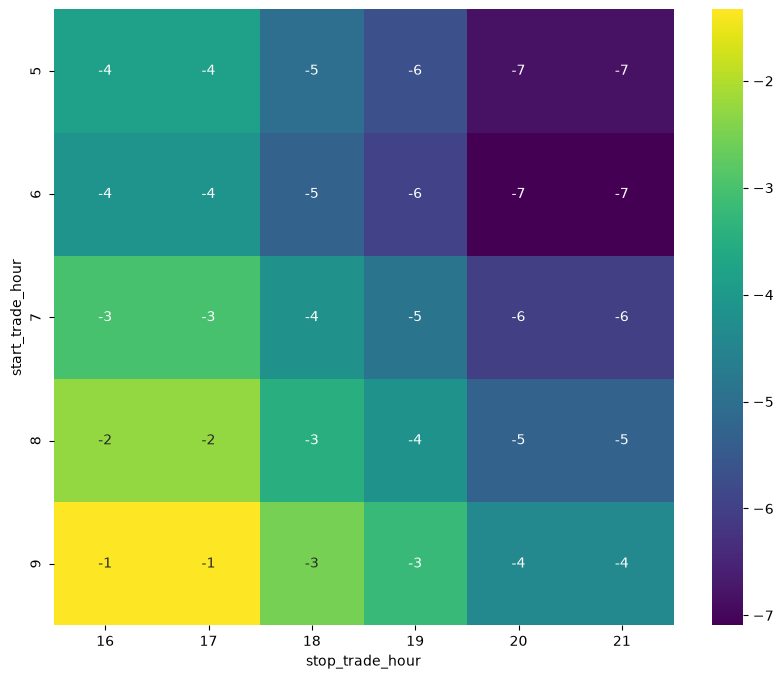

In [12]:
bt = Backtest(df_h1, MyStrat, cash=10000, margin=1/10, commission=0.001) #0.0002
stats, heatmap = bt.optimize(start_trade_hour=[i for i in range(5, 10)],
                    stop_trade_hour=[i for i in range(16, 22)],
                    maximize='Return [%]', max_tries=300,
                        random_state=0,
                        return_heatmap=True)

# Convert multiindex series to dataframe
heatmap_df = heatmap.unstack()
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_df, annot=True, cmap='viridis', fmt='.0f')
plt.show()